# Gold Layer Analysis — Business Insights

This notebook queries the **gold layer** (star schema) of the ecommerce analytics pipeline and visualizes key business metrics.

**SQL techniques demonstrated:** Window functions (`RANK`, `LAG`, `NTILE`, `AVG OVER ROWS BETWEEN`), multi-level CTEs, conditional aggregation, cumulative distributions, complex multi-table joins.

**Views used:** `gold.analysis_daily_revenue`, `gold.analysis_product_profitability`, `gold.analysis_refund_rates`, `gold.analysis_customer_segments`, `gold.analysis_country_performance`

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

con = duckdb.connect("data/analytics.duckdb", read_only=True)
print("Connected to analytics.duckdb")

Connected to analytics.duckdb


## 1. Daily Revenue Trend with 7-Day Moving Average

Revenue time series with a rolling 7-day average to smooth daily noise, plus day-over-day growth percentage.

**SQL:** `LAG()` for DoD comparison, `AVG() OVER (ROWS BETWEEN 6 PRECEDING AND CURRENT ROW)` for moving average.

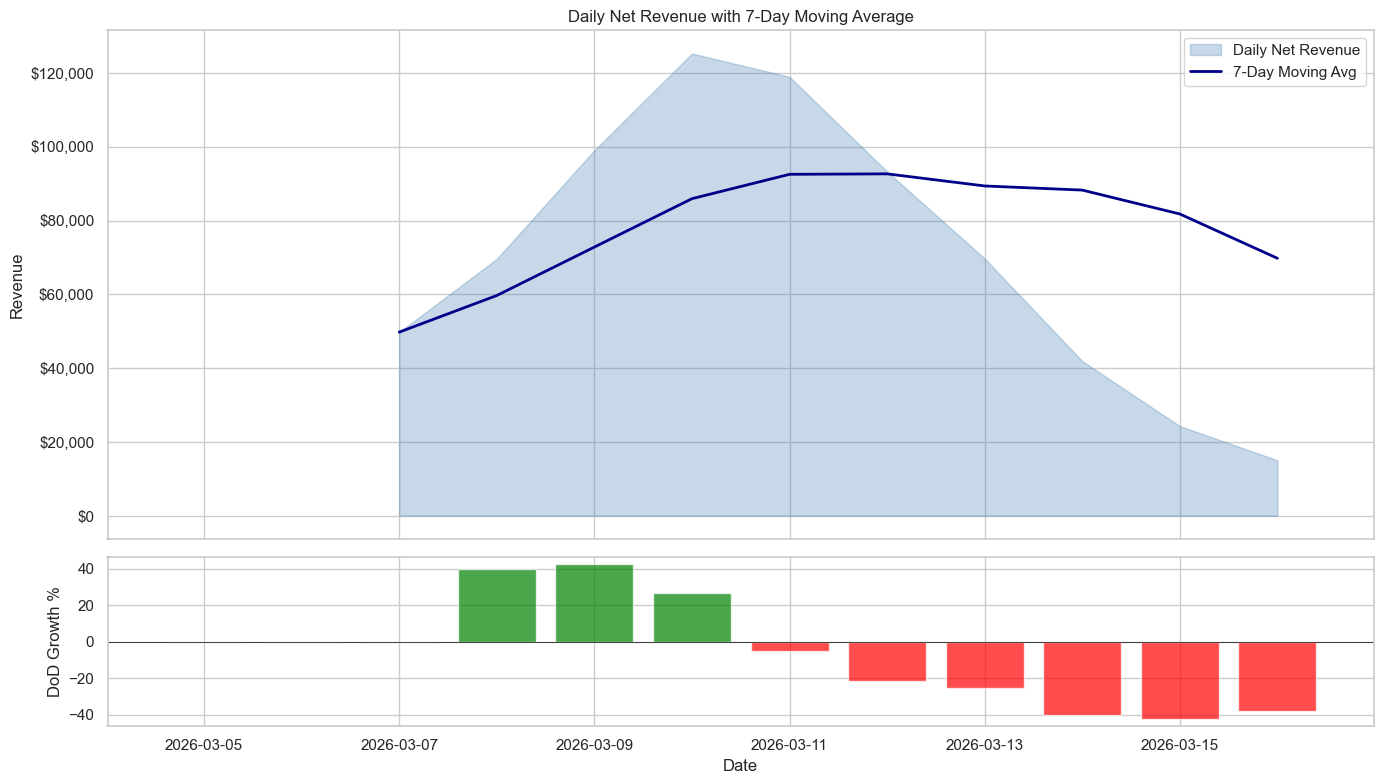

In [2]:
daily = con.sql("SELECT * FROM gold.analysis_daily_revenue").df()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

# Revenue + 7-day MA
ax1.fill_between(daily["order_date"], daily["net_revenue"], alpha=0.3, color="steelblue", label="Daily Net Revenue")
ax1.plot(daily["order_date"], daily["net_revenue_7d_ma"], color="darkblue", linewidth=2, label="7-Day Moving Avg")
ax1.set_ylabel("Revenue")
ax1.set_title("Daily Net Revenue with 7-Day Moving Average")
ax1.legend()
ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

# DoD growth %
colors = ["green" if x >= 0 else "red" for x in daily["revenue_dod_growth_pct"].fillna(0)]
ax2.bar(daily["order_date"], daily["revenue_dod_growth_pct"].fillna(0), color=colors, alpha=0.7)
ax2.axhline(0, color="black", linewidth=0.5)
ax2.set_ylabel("DoD Growth %")
ax2.set_xlabel("Date")

plt.tight_layout()
plt.show()

## 2. Product Profitability — Top 15 by Net Revenue

Margin analysis joining fact and dimension tables with `RANK()` partitioned by category.

**SQL:** CTE for aggregation, `RANK() OVER (PARTITION BY product_type)`, percentage-of-total via `SUM() OVER()`.

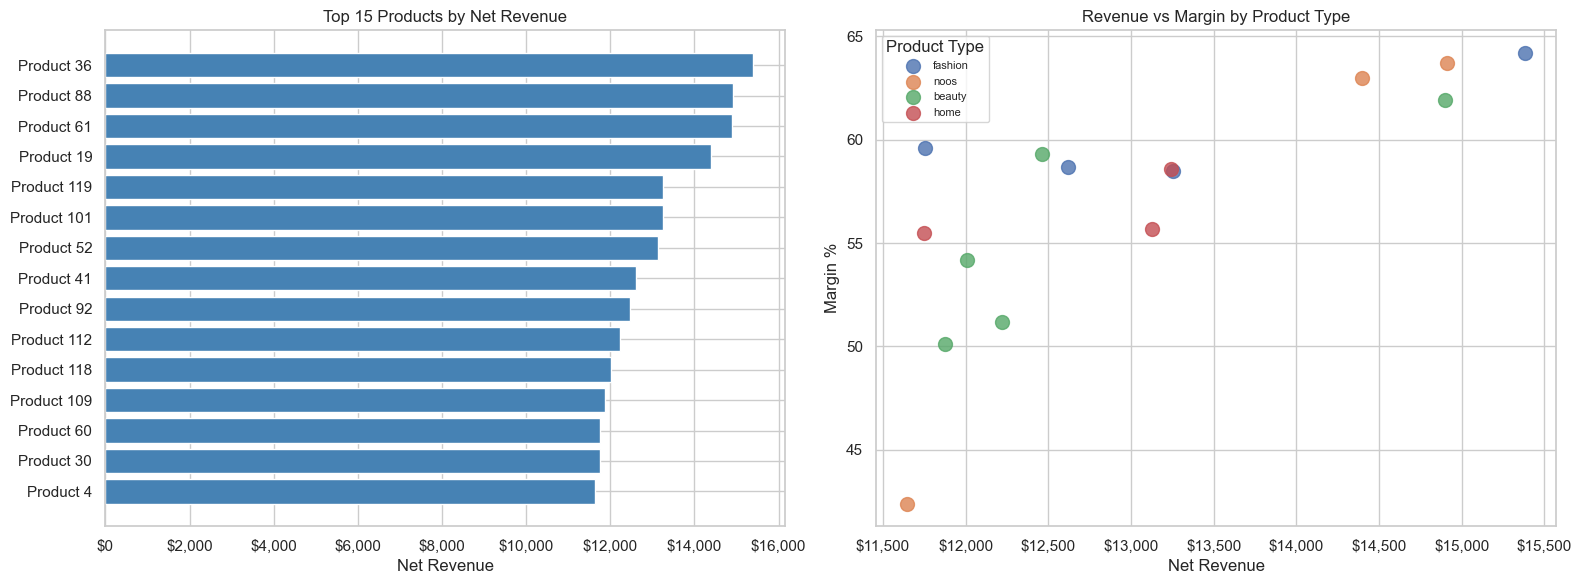

In [3]:
profit = con.sql("SELECT * FROM gold.analysis_product_profitability ORDER BY net_revenue DESC LIMIT 15").df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Revenue bars
bars = ax1.barh(profit["product_name"], profit["net_revenue"], color="steelblue")
ax1.set_xlabel("Net Revenue")
ax1.set_title("Top 15 Products by Net Revenue")
ax1.invert_yaxis()
ax1.xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

# Margin scatter by category
for cat in profit["product_type"].unique():
    mask = profit["product_type"] == cat
    ax2.scatter(profit.loc[mask, "net_revenue"], profit.loc[mask, "margin_pct"],
                label=cat, s=100, alpha=0.8)
ax2.set_xlabel("Net Revenue")
ax2.set_ylabel("Margin %")
ax2.set_title("Revenue vs Margin by Product Type")
ax2.legend(title="Product Type", fontsize=8)
ax2.xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

plt.tight_layout()
plt.show()

In [4]:
# Category-level summary
cat_summary = con.sql("""
    SELECT
        product_type
        ,COUNT(*) AS product_count
        ,SUM(units_sold) AS total_units
        ,SUM(net_revenue) AS total_revenue
        ,SUM(gross_profit) AS total_profit
        ,ROUND(SUM(gross_profit) / NULLIF(SUM(net_revenue), 0) * 100, 1) AS avg_margin_pct
    FROM gold.analysis_product_profitability
    GROUP BY product_type
    ORDER BY total_revenue DESC
""").df()
display(cat_summary)

,product_type,product_count,total_units,total_revenue,total_profit,avg_margin_pct
0,beauty,37,1808.0,245730.86,124419.14,50.6
1,noos,33,1490.0,193618.97,94045.02,48.6
2,home,27,1293.0,160965.52,79229.84,49.2
3,fashion,23,1073.0,144056.78,69104.47,48.0


## 3. Refund Rate Analysis

Which product types and countries have the highest refund rates? Helps identify quality or fulfillment issues.

**SQL:** Multi-table JOIN across facts and dimensions, `COALESCE` for null-safe aggregation, ratio calculations.

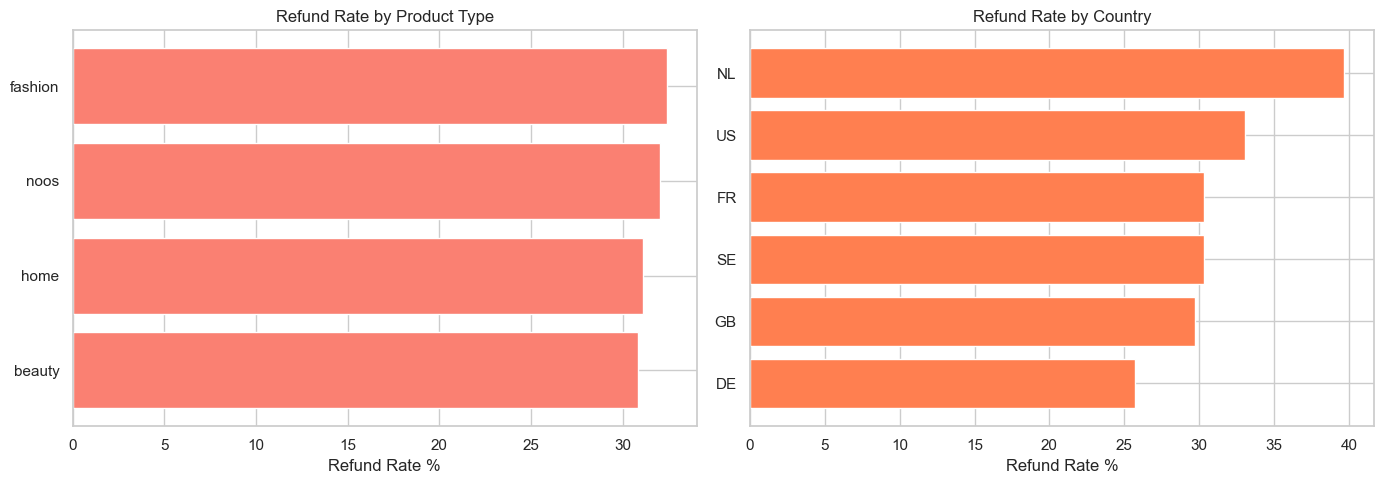

In [5]:
# Refund rates by product type
refund_by_type = con.sql("""
    SELECT
        product_type
        ,SUM(total_lines) AS total_lines
        ,SUM(refund_count) AS total_refunds
        ,ROUND(SUM(refund_count)::FLOAT / NULLIF(SUM(total_lines), 0) * 100, 1) AS refund_rate_pct
        ,SUM(refund_amount) AS total_refund_amount
    FROM gold.analysis_refund_rates
    GROUP BY product_type
    ORDER BY refund_rate_pct DESC
""").df()

# Refund rates by country
refund_by_country = con.sql("""
    SELECT
        country
        ,SUM(total_lines) AS total_lines
        ,SUM(refund_count) AS total_refunds
        ,ROUND(SUM(refund_count)::FLOAT / NULLIF(SUM(total_lines), 0) * 100, 1) AS refund_rate_pct
        ,SUM(refund_amount) AS total_refund_amount
    FROM gold.analysis_refund_rates
    GROUP BY country
    ORDER BY refund_rate_pct DESC
""").df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(refund_by_type["product_type"], refund_by_type["refund_rate_pct"], color="salmon")
ax1.set_xlabel("Refund Rate %")
ax1.set_title("Refund Rate by Product Type")
ax1.invert_yaxis()

ax2.barh(refund_by_country["country"], refund_by_country["refund_rate_pct"], color="coral")
ax2.set_xlabel("Refund Rate %")
ax2.set_title("Refund Rate by Country")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

## 4. Customer Segmentation

Customers segmented by lifetime spend (`NTILE` quartiles) and order frequency. Identifies high-value vs one-time buyers.

**SQL:** Multi-level CTEs, `NTILE(4)` for spend quartiles, `DATEDIFF` for tenure, `CASE` for frequency bucketing.

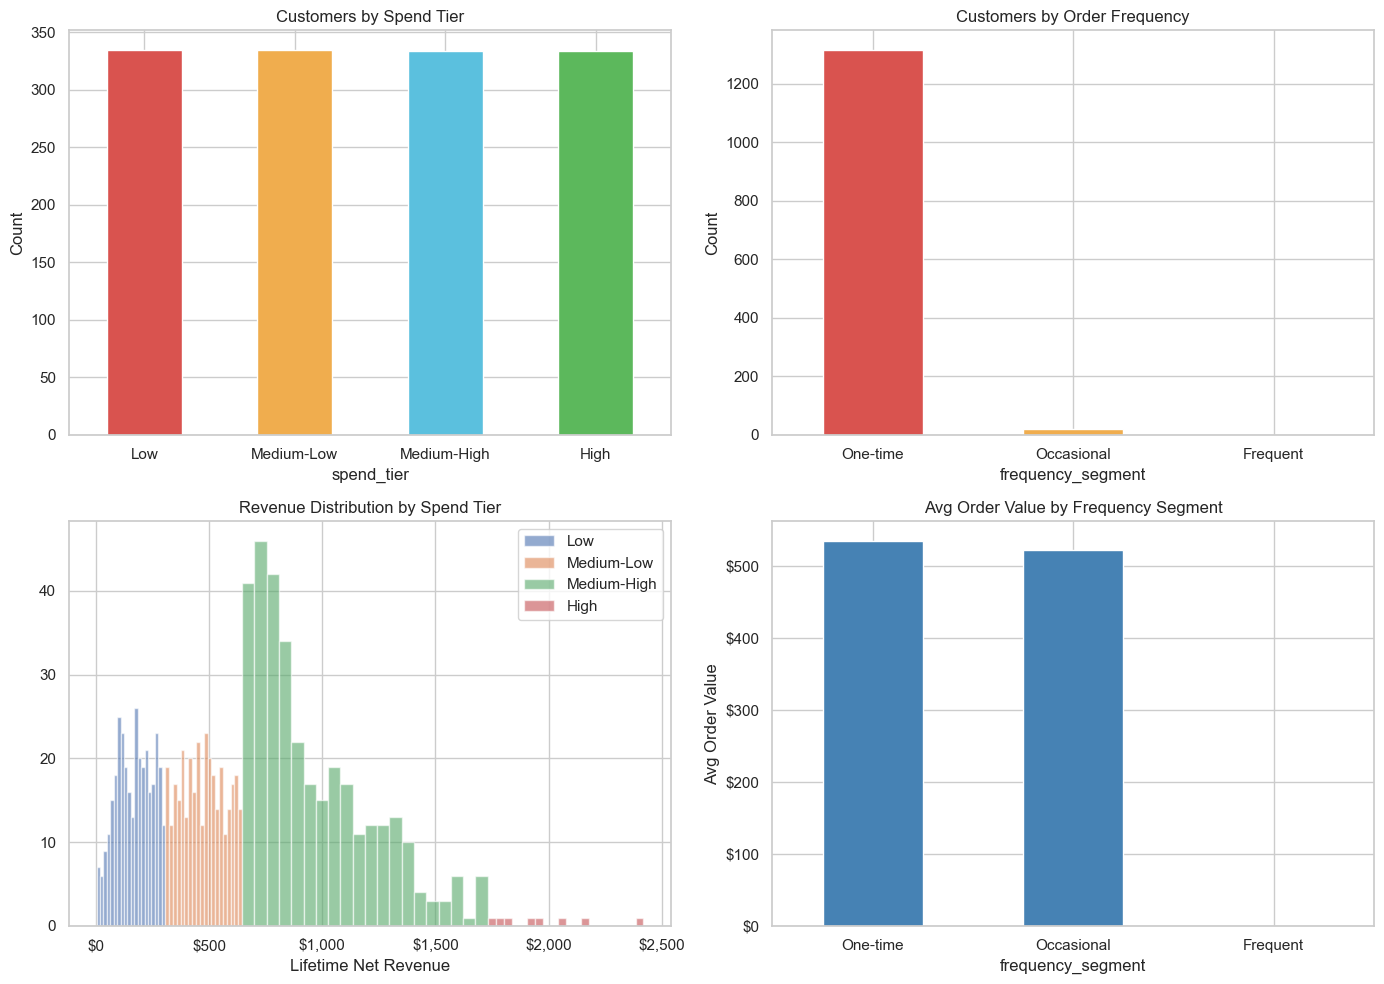

In [6]:
customers = con.sql("SELECT * FROM gold.analysis_customer_segments").df()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Spend tier distribution
tier_counts = customers["spend_tier"].value_counts().reindex(["Low", "Medium-Low", "Medium-High", "High"])
tier_counts.plot.bar(ax=axes[0, 0], color=["#d9534f", "#f0ad4e", "#5bc0de", "#5cb85c"])
axes[0, 0].set_title("Customers by Spend Tier")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis="x", rotation=0)

# Frequency segment
freq_counts = customers["frequency_segment"].value_counts().reindex(["One-time", "Occasional", "Frequent"])
freq_counts.plot.bar(ax=axes[0, 1], color=["#d9534f", "#f0ad4e", "#5cb85c"])
axes[0, 1].set_title("Customers by Order Frequency")
axes[0, 1].set_ylabel("Count")
axes[0, 1].tick_params(axis="x", rotation=0)

# Lifetime revenue distribution by spend tier
for tier in ["Low", "Medium-Low", "Medium-High", "High"]:
    subset = customers[customers["spend_tier"] == tier]["lifetime_net_revenue"]
    axes[1, 0].hist(subset, bins=20, alpha=0.6, label=tier)
axes[1, 0].set_xlabel("Lifetime Net Revenue")
axes[1, 0].set_title("Revenue Distribution by Spend Tier")
axes[1, 0].legend()
axes[1, 0].xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

# AOV by frequency segment
aov_by_freq = customers.groupby("frequency_segment")["avg_order_value"].mean().reindex(
    ["One-time", "Occasional", "Frequent"])
aov_by_freq.plot.bar(ax=axes[1, 1], color="steelblue")
axes[1, 1].set_title("Avg Order Value by Frequency Segment")
axes[1, 1].set_ylabel("Avg Order Value")
axes[1, 1].tick_params(axis="x", rotation=0)
axes[1, 1].yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

plt.tight_layout()
plt.show()

In [7]:
# Segment summary table
seg_summary = con.sql("""
    SELECT
        spend_tier
        ,frequency_segment
        ,COUNT(*) AS customer_count
        ,ROUND(AVG(lifetime_net_revenue), 2) AS avg_ltv
        ,ROUND(AVG(avg_order_value), 2) AS avg_aov
        ,ROUND(AVG(order_count), 1) AS avg_orders
    FROM gold.analysis_customer_segments
    GROUP BY spend_tier, frequency_segment
    ORDER BY avg_ltv DESC
""").df()
display(seg_summary)

,spend_tier,frequency_segment,customer_count,avg_ltv,avg_aov,avg_orders
0,High,One-time,334,1985.90,1985.90,1.0
1,Medium-High,Occasional,16,1251.04,625.52,2.0
2,Medium-High,One-time,318,947.92,947.92,1.0
3,Medium-Low,Occasional,5,546.72,273.36,2.0
4,Medium-Low,One-time,330,473.24,473.24,1.0
5,Low,Occasional,1,209.51,104.76,2.0
6,Low,One-time,334,167.84,167.84,1.0


## 5. Country Performance — Revenue Concentration (Pareto)

ABC tiering of countries by cumulative revenue share: A-tier (top 80%), B-tier (80-95%), C-tier (tail).

**SQL:** `DENSE_RANK`, cumulative `SUM() OVER (ORDER BY ...)`, `CASE` for ABC classification.

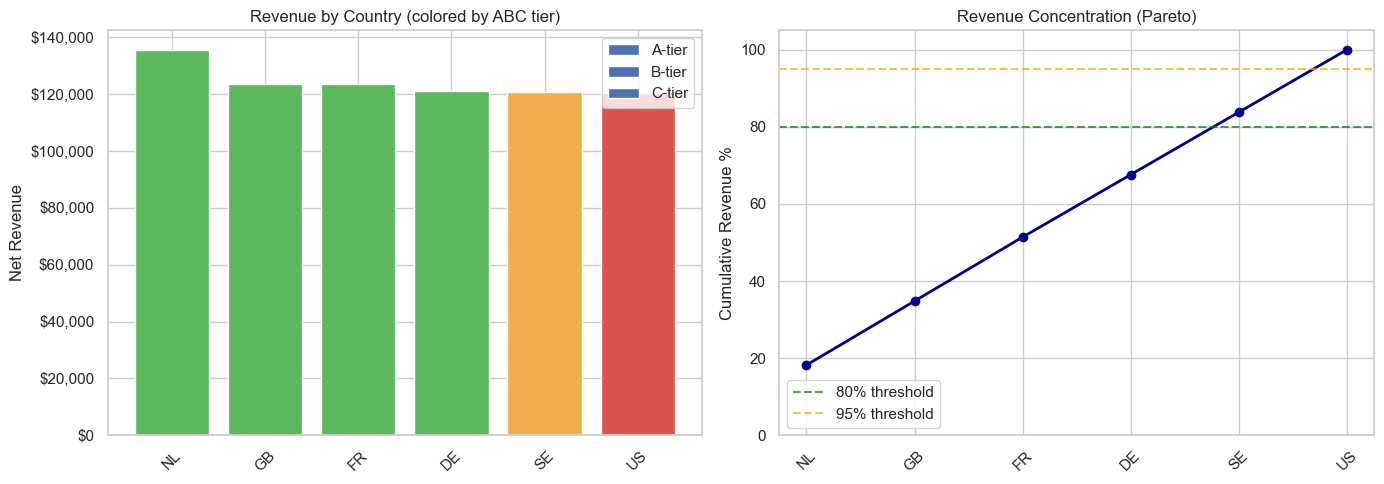

In [8]:
countries = con.sql("SELECT * FROM gold.analysis_country_performance").df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Revenue by country with tier coloring
tier_colors = {"A-tier": "#5cb85c", "B-tier": "#f0ad4e", "C-tier": "#d9534f"}
bar_colors = [tier_colors.get(t, "gray") for t in countries["country_tier"]]
ax1.bar(countries["country"], countries["net_revenue"], color=bar_colors)
ax1.set_ylabel("Net Revenue")
ax1.set_title("Revenue by Country (colored by ABC tier)")
ax1.tick_params(axis="x", rotation=45)
ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

# Add tier legend
for tier, color in tier_colors.items():
    ax1.bar([], [], color=color, label=tier)
ax1.legend()

# Pareto curve
ax2.plot(countries["country"], countries["cumulative_pct"], marker="o", color="darkblue", linewidth=2)
ax2.axhline(80, color="green", linestyle="--", alpha=0.7, label="80% threshold")
ax2.axhline(95, color="orange", linestyle="--", alpha=0.7, label="95% threshold")
ax2.set_ylabel("Cumulative Revenue %")
ax2.set_title("Revenue Concentration (Pareto)")
ax2.tick_params(axis="x", rotation=45)
ax2.legend()
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()

In [9]:
# Country detail table
display(countries[["country", "country_tier", "order_count", "customer_count",
                   "net_revenue", "avg_order_value", "pct_of_total", "cumulative_pct"]])

,country,country_tier,order_count,customer_count,net_revenue,avg_order_value,pct_of_total,cumulative_pct
0,NL,A-tier,223,223,135585.96,611.96,18.2,18.2
1,GB,A-tier,220,219,123519.73,565.24,16.6,34.8
2,FR,A-tier,228,227,123353.56,544.31,16.6,51.4
3,DE,A-tier,234,234,121024.32,521.17,16.3,67.6
4,SE,B-tier,228,228,120594.07,532.19,16.2,83.8
5,US,C-tier,227,226,120294.49,533.55,16.2,100.0


## 6. Executive Summary

High-level KPIs computed directly from the gold layer.

In [10]:
con.sql("""
    SELECT
        COUNT(DISTINCT o.order_id)                                              AS total_orders
        ,COUNT(DISTINCT o.customer_id)                                          AS unique_customers
        ,COUNT(DISTINCT p.product_id)                                           AS products_sold
        ,SUM(CAST(f.quantity AS INT))                                           AS total_units
        ,ROUND(SUM(CAST(f.quantity AS INT) * CAST(f.unit_price AS DECIMAL(10,2))), 2)    AS gross_revenue
        ,ROUND(SUM(CAST(f.quantity AS INT) * CAST(f.unit_price AS DECIMAL(10,2)))
         - SUM(CAST(f.line_discount_amount AS DECIMAL(10,2))), 2)              AS net_revenue
        ,(SELECT COUNT(*) FROM gold.FactRefund)                                 AS total_refunds
        ,(SELECT ROUND(SUM(CAST(refund_amount AS DECIMAL(10,2))), 2)
          FROM gold.FactRefund)                                                 AS total_refund_value
    FROM gold.FactOrderLine f
    JOIN gold.DimOrder o ON o.order_sk = f.order_sk
    JOIN gold.DimProduct p ON p.product_sk = f.product_sk
    WHERE f.order_sk != -1 AND f.product_sk != -1
""").show()

┌──────────────┬──────────────────┬───────────────┬─────────────┬───────────────┬───────────────┬───────────────┬────────────────────┐
│ total_orders │ unique_customers │ products_sold │ total_units │ gross_revenue │  net_revenue  │ total_refunds │ total_refund_value │
│    int64     │      int64       │     int64     │   int128    │ decimal(38,2) │ decimal(38,2) │     int64     │   decimal(38,2)    │
├──────────────┼──────────────────┼───────────────┼─────────────┼───────────────┼───────────────┼───────────────┼────────────────────┤
│         1360 │             1338 │           120 │        5664 │     749329.63 │     744372.13 │           376 │           39551.61 │
└──────────────┴──────────────────┴───────────────┴─────────────┴───────────────┴───────────────┴───────────────┴────────────────────┘



In [11]:
con.close()
print("Connection closed.")

Connection closed.
